[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/07-generative/01_vae_and_diffusion.ipynb)

# Compression, a Latent With a Shape, and Learned Denoising

**Session 27 · no homework grades this · CPU only**

Three models, in the order the ideas arrived:

1. an **autoencoder**, which compresses and reconstructs but cannot generate;
2. a **VAE**, which adds one term to the loss and can;
3. **diffusion**, which gives up on a single-step decoder entirely and learns to
   remove noise instead.

Everything below runs on a laptop CPU in under a minute. The `diffusers`
pipeline that produces the pictures people mean by "diffusion" is a GPU job with
a multi-gigabyte download; it appears at the end as code to read, not to run.

torch 2.5.1 | data (1797, 64) | range 0.0 to 1.0


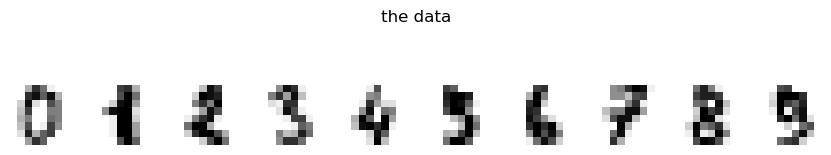

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import load_digits

torch.manual_seed(27)
rng = np.random.default_rng(27)

digits = load_digits()
images = digits.data.astype("float32") / 16.0        # 8x8, values in [0, 1]
X = torch.from_numpy(images)
print("torch", torch.__version__, "| data", tuple(X.shape), "| range",
      float(X.min()), "to", float(X.max()))

def show(batch, title, n=10):
    fig, axes = plt.subplots(1, n, figsize=(n * 0.85, 1.2))
    for ax, img in zip(axes, batch[:n]):
        ax.imshow(np.asarray(img).reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title, y=1.25)
    plt.tight_layout(); plt.show()

show(X, "the data")

## 1. An autoencoder learns a code, not a distribution

final reconstruction MSE: 0.02282


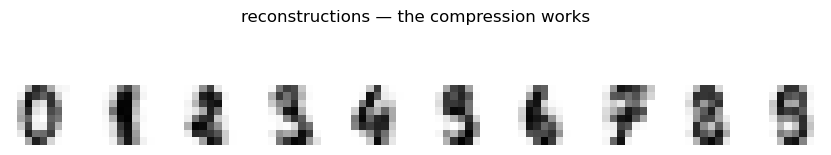

In [2]:
class AutoEncoder(nn.Module):
    def __init__(self, latent=8):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, latent))
        self.decoder = nn.Sequential(nn.Linear(latent, 32), nn.ReLU(),
                                     nn.Linear(32, 64), nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))


auto = AutoEncoder()
opt = torch.optim.AdamW(auto.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()

for epoch in range(400):
    opt.zero_grad()
    loss = loss_fn(auto(X), X)
    loss.backward()
    opt.step()

print(f"final reconstruction MSE: {loss.item():.5f}")
with torch.no_grad():
    show(auto(X).numpy(), "reconstructions — the compression works")

Sixty-four pixels through an eight-dimensional bottleneck and back, recognisably.
Now ask it to *generate*: sample a code from a standard normal and decode it.

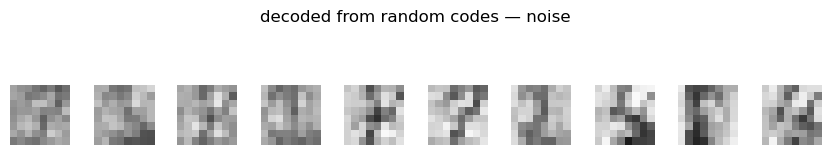

codes the encoder actually produces: mean 3.49, std 2.43
per-dimension std: [1.68 1.33 1.77 1.49 1.1  1.57 2.14 1.41]


In [3]:
with torch.no_grad():
    fake_codes = torch.randn(10, 8)
    show(auto.decoder(fake_codes).numpy(), "decoded from random codes — noise")

    real_codes = auto.encoder(X)
    print(f"codes the encoder actually produces: mean {real_codes.mean():.2f}, "
          f"std {real_codes.std():.2f}")
    print(f"per-dimension std: {real_codes.std(0).numpy().round(2)}")

The decoder was trained only on the codes the encoder happens to produce, and
those occupy some irregular region of the eight-dimensional space — not the unit
ball we sampled from. Between the islands the decoder has never been asked
anything, and it answers with mush.

**That is the gap a VAE closes:** not by improving the decoder, but by forcing
the encoder's output distribution to be one we know how to sample from.

## 2. The VAE: a latent with a shape

Two changes. The encoder emits a mean and a log-variance rather than a point,
and the loss gains a KL term pulling that distribution toward `N(0, I)`. The
reparameterisation `z = mu + sigma * eps` is what keeps it differentiable.

In [4]:
class VAE(nn.Module):
    def __init__(self, latent=8):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(64, 32), nn.ReLU())
        self.to_mu = nn.Linear(32, latent)
        self.to_logvar = nn.Linear(32, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, 32), nn.ReLU(),
                                     nn.Linear(32, 64), nn.Sigmoid())

    def encode(self, x):
        h = self.body(x)
        return self.to_mu(h), self.to_logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)          # reparameterisation
        return self.decoder(z), mu, logvar


def fit_vae(beta, steps=1200, seed=0):
    torch.manual_seed(seed)
    model = VAE()
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
    for _ in range(steps):
        opt.zero_grad()
        recon, mu, logvar = model(X)
        recon_loss = nn.functional.binary_cross_entropy(recon, X, reduction="sum") / len(X)
        kl = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1)).mean()
        (recon_loss + beta * kl).backward()
        opt.step()
    return model, recon_loss.item(), kl.item()


results = {}
for beta in (0.0, 0.5, 1.0, 4.0):
    model, recon, kl = fit_vae(beta)
    results[beta] = model
    print(f"beta = {beta:>4}   reconstruction {recon:>7.2f}   KL {kl:>7.3f}")

beta =  0.0   reconstruction   17.19   KL 198.213


beta =  0.5   reconstruction   19.55   KL   5.551


beta =  1.0   reconstruction   21.24   KL   3.071


beta =  4.0   reconstruction   27.13   KL   0.001


Read the two columns against each other. `beta = 0` is an autoencoder with extra
steps: the best reconstruction and a KL term left to grow unchecked. As beta
rises the reconstruction gets worse and the latent gets closer to the prior.
That is the trade, and it is not a bug to be tuned away — it is the whole design.

Now sample from the prior for each:

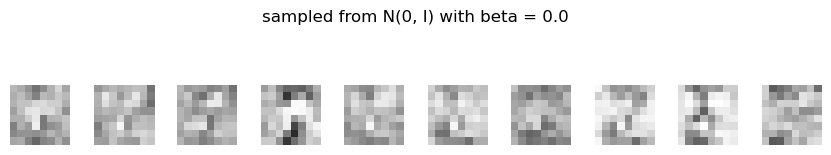

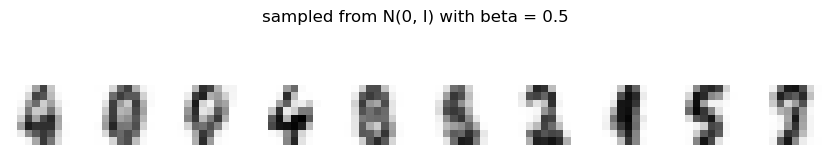

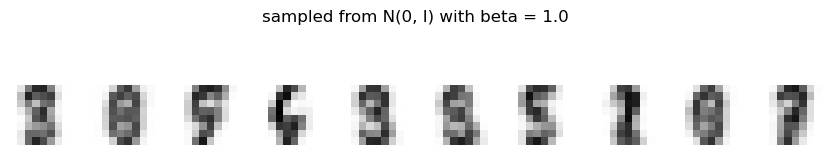

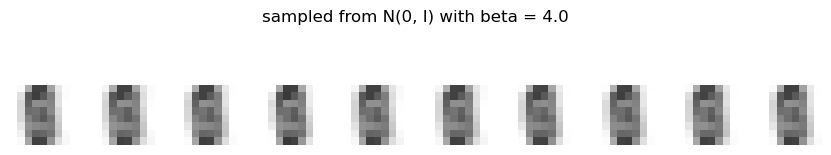

In [5]:
torch.manual_seed(3)
noise = torch.randn(10, 8)
for beta, model in results.items():
    with torch.no_grad():
        show(model.decoder(noise).numpy(), f"sampled from N(0, I) with beta = {beta}")

At `beta = 0` the samples are the same mush as the plain autoencoder — nothing
constrained the latent, so the prior is the wrong distribution to sample from.
By `beta = 1` the samples look like digits, because now the region we are
sampling from is the region the decoder was trained on. At `beta = 4` they get
smoother and less varied: the KL term has won outright, the encoder has stopped
distinguishing inputs, and the decoder is producing one average digit whatever
you feed it. That failure has a name — **posterior collapse** — and the table
below is how you detect it without squinting at pictures.

**Measure it rather than eyeballing it.** How close is the aggregate posterior
to the prior?

In [6]:
print(f"{'beta':>5} {'mean|mu|':>10} {'std of z':>10} {'recon MSE':>11}")
for beta, model in results.items():
    with torch.no_grad():
        mu, logvar = model.encode(X)
        recon, _, _ = model(X)
        print(f"{beta:>5} {mu.abs().mean():>10.3f} {mu.std():>10.3f} "
              f"{nn.functional.mse_loss(recon, X):>11.5f}")
print("\nprior would give mean|mu| ~ 0.80 and std 1.00 for a standard normal")

 beta   mean|mu|   std of z   recon MSE
  0.0      5.214      6.131     0.01549
  0.5      0.597      0.806     0.02816
  1.0      0.408      0.636     0.03781
  4.0      0.006      0.007     0.07335

prior would give mean|mu| ~ 0.80 and std 1.00 for a standard normal


## 3. Diffusion: destroy the data, then learn to rebuild it

A different bargain. Instead of one decoder that must map noise to data in a
single step, define a fixed process that gradually turns data into noise, and
train a network to undo one step of it.

Two dimensions, so the whole thing is visible. The data is a spiral — no
Gaussian, no ellipse, nothing a mixture would find.

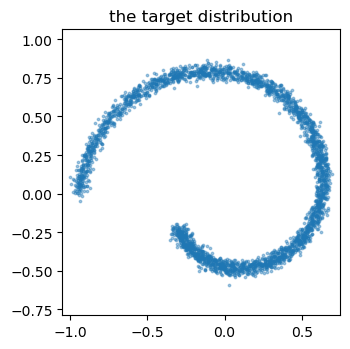

In [7]:
t_param = rng.uniform(0.4, 1.0, 3000) * 3 * np.pi
spiral = np.stack([t_param * np.cos(t_param), t_param * np.sin(t_param)], 1)
spiral += rng.normal(0, 0.25, spiral.shape)
spiral = (spiral / np.abs(spiral).max()).astype("float32")
data = torch.from_numpy(spiral)

plt.figure(figsize=(3.6, 3.6))
plt.scatter(*spiral.T, s=3, alpha=.4)
plt.title("the target distribution"); plt.axis("equal"); plt.tight_layout(); plt.show()

### The forward process is arithmetic, not learning

`x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps`. Because the
schedule is fixed, any timestep can be reached in one step — no simulation.

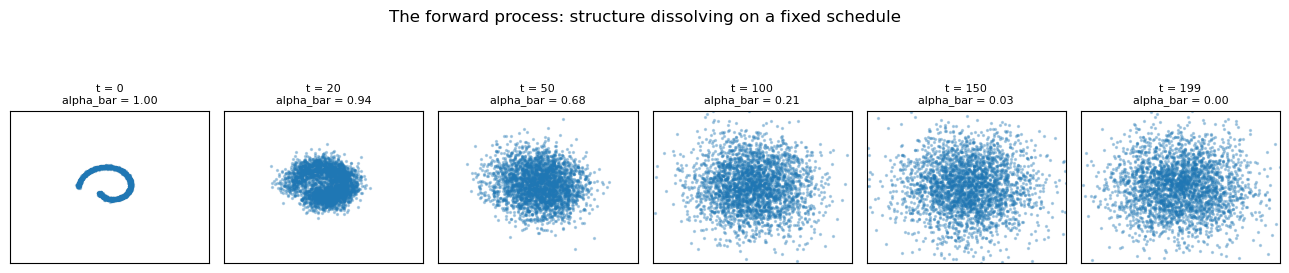

In [8]:
T = 200
betas = torch.linspace(1e-4, 0.06, T)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, 0)

fig, axes = plt.subplots(1, 6, figsize=(13, 2.4))
for ax, t in zip(axes, [0, 20, 50, 100, 150, 199]):
    ab = alpha_bar[t]
    noisy = ab.sqrt() * data + (1 - ab).sqrt() * torch.randn_like(data)
    ax.scatter(*noisy.T.numpy(), s=2, alpha=.3)
    ax.set_title(f"t = {t}\nalpha_bar = {ab:.2f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
fig.suptitle("The forward process: structure dissolving on a fixed schedule", y=1.12)
plt.tight_layout(); plt.show()

### The reverse process is the only thing learned

The network sees a noisy point and its timestep, and predicts the noise that was
added. That is the entire training objective.

final noise-prediction MSE: 0.1995


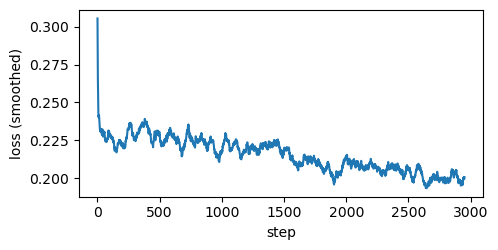

In [9]:
class Denoiser(nn.Module):
    def __init__(self, width=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, width), nn.SiLU(),
                                 nn.Linear(width, width), nn.SiLU(),
                                 nn.Linear(width, 2))

    def forward(self, x, t):
        t_scaled = (t.float() / T).unsqueeze(1)
        return self.net(torch.cat([x, t_scaled], dim=1))


torch.manual_seed(0)
denoiser = Denoiser()
opt = torch.optim.AdamW(denoiser.parameters(), lr=2e-3)

losses = []
for step in range(3000):
    idx = torch.randint(0, len(data), (256,))
    x0 = data[idx]
    t = torch.randint(0, T, (256,))
    eps = torch.randn_like(x0)
    ab = alpha_bar[t].unsqueeze(1)
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps

    opt.zero_grad()
    loss = nn.functional.mse_loss(denoiser(xt, t), eps)
    loss.backward()
    opt.step()
    losses.append(loss.item())

print(f"final noise-prediction MSE: {np.mean(losses[-100:]):.4f}")
plt.figure(figsize=(5, 2.6))
plt.plot(np.convolve(losses, np.ones(50) / 50, "valid"))
plt.xlabel("step"); plt.ylabel("loss (smoothed)"); plt.tight_layout(); plt.show()

### Sampling: walk the schedule backwards

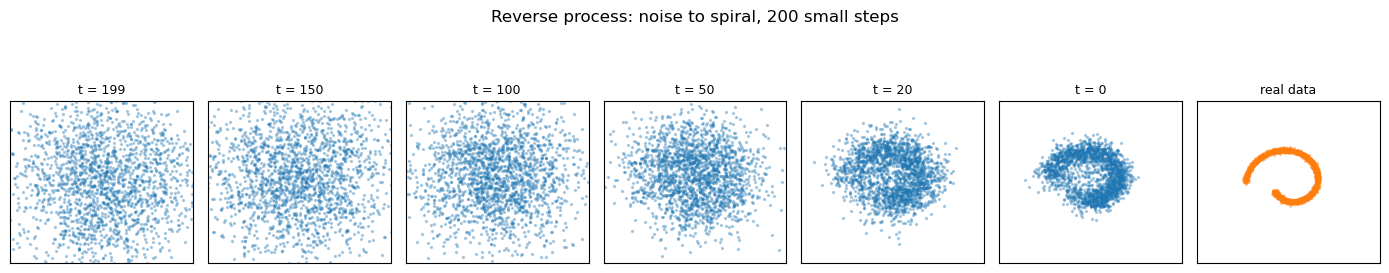

In [10]:
@torch.no_grad()
def sample(n=2000, keep=(199, 150, 100, 50, 20, 0)):
    x = torch.randn(n, 2)
    snapshots = {}
    for t in reversed(range(T)):
        eps_hat = denoiser(x, torch.full((n,), t, dtype=torch.long))
        mean = (x - (betas[t] / (1 - alpha_bar[t]).sqrt()) * eps_hat) / alphas[t].sqrt()
        x = mean + betas[t].sqrt() * torch.randn_like(x) if t > 0 else mean
        if t in keep:
            snapshots[t] = x.clone()
    return x, snapshots


generated, snapshots = sample()

fig, axes = plt.subplots(1, len(snapshots) + 1, figsize=(14, 2.4))
for ax, (t, pts) in zip(axes, sorted(snapshots.items(), reverse=True)):
    ax.scatter(*pts.T.numpy(), s=2, alpha=.3)
    ax.set_title(f"t = {t}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
axes[-1].scatter(*spiral.T, s=2, alpha=.3, color="tab:orange")
axes[-1].set_title("real data", fontsize=9)
axes[-1].set_xticks([]); axes[-1].set_yticks([]); axes[-1].set_xlim(-2, 2); axes[-1].set_ylim(-2, 2)
fig.suptitle("Reverse process: noise to spiral, 200 small steps", y=1.12)
plt.tight_layout(); plt.show()

Noise at the left, a spiral at the right, and nothing in the model that knows
what a spiral is. Every step was "predict the noise, subtract a little of it".

A quick numerical check that the samples resemble the data rather than just
looking like it — compare the distribution of distances from the origin:

radius   real: mean 0.664  std 0.164
         fake: mean 0.662  std 0.220


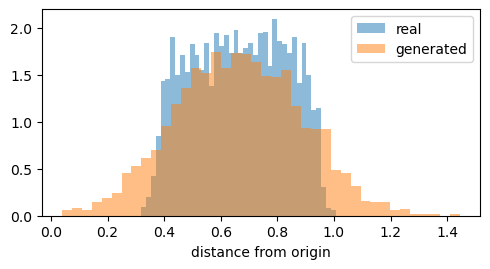

In [11]:
real_radius = np.linalg.norm(spiral, axis=1)
fake_radius = np.linalg.norm(generated.numpy(), axis=1)
print(f"radius   real: mean {real_radius.mean():.3f}  std {real_radius.std():.3f}")
print(f"         fake: mean {fake_radius.mean():.3f}  std {fake_radius.std():.3f}")

plt.figure(figsize=(5, 2.8))
plt.hist(real_radius, bins=40, alpha=.5, density=True, label="real")
plt.hist(fake_radius, bins=40, alpha=.5, density=True, label="generated")
plt.xlabel("distance from origin"); plt.legend(); plt.tight_layout(); plt.show()

## 4. The same idea, at scale — read, do not run

Everything above is the mechanism. What people mean by "diffusion" adds three
things this toy does not have: a U-Net instead of three linear layers, a latent
space so the denoising happens on compressed representations rather than pixels,
and text conditioning through cross-attention.

The API is small, which is the point — and it is also why the interesting parts
are invisible from here:

```python
# NOT RUN in this notebook: needs a GPU and a multi-gigabyte download.
# Pin the revision, or you are not running the model you documented.
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    revision="main",                 # pin a commit sha in real work
    torch_dtype=torch.float16,
)
pipe = pipe.to("cuda")

image = pipe(
    "a watercolour of the Palouse in September",
    num_inference_steps=30,          # the loop you wrote above
    guidance_scale=7.5,              # classifier-free guidance
    generator=torch.Generator("cuda").manual_seed(0),
).images[0]
```

`num_inference_steps` is the reverse loop from section 3. `guidance_scale` is
classifier-free guidance: run the denoiser twice, once with the prompt and once
without, and extrapolate away from the unconditional prediction. The arithmetic
is the arithmetic you just wrote.

**If you run this yourself:** budget the download (several GB), pin the
revision, and note that the licence and the training data are part of what you
are adopting.

## What to take from this

- An autoencoder learns a code. It cannot generate, because nothing constrains
  where the codes live.
- The KL term is what makes the prior a valid place to sample from, and it
  trades directly against reconstruction. Report both numbers.
- Diffusion replaces one hard mapping with many easy ones. The forward process
  is fixed arithmetic; only noise prediction is learned.
- The toy and the production system differ in scale and conditioning, not in
  mechanism.

## Where to go next

- **Reading, Session 27** — the derivation of the VAE objective and the
  diffusion schedule.
- **Depth page: GANs and vision-language models** — the branch this course does
  not lecture, if you want it.
- **Session 28** — generative models you call rather than train.